# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [1]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [2]:
filename="../Lab.7/SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
          "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
df = pd.read_csv(filename, dtype='float64', names=VarNames)

In [3]:
print(df.shape) 

(5000000, 19)


## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

In [4]:
import sklearn
print(sklearn.__version__)

1.7.2


### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [5]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [6]:
N_Train=4000000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:]

X_Train=Train_Sample[VarNames[1:]]
y_Train=Train_Sample["signal"]

X_Test=Test_Sample[VarNames[1:]]
y_Test=Test_Sample["signal"]

Test_sig=Test_Sample[Test_Sample.signal==1]
Test_bkg=Test_Sample[Test_Sample.signal==0]


We can train the classifier as follow:

In [7]:
Fisher.fit(X_Train,y_Train)

,solver,'svd'
,shrinkage,None
,priors,None
,n_components,None
,store_covariance,False
,tol,0.0001
,covariance_estimator,None


We can plot the output, comparing signal and background:

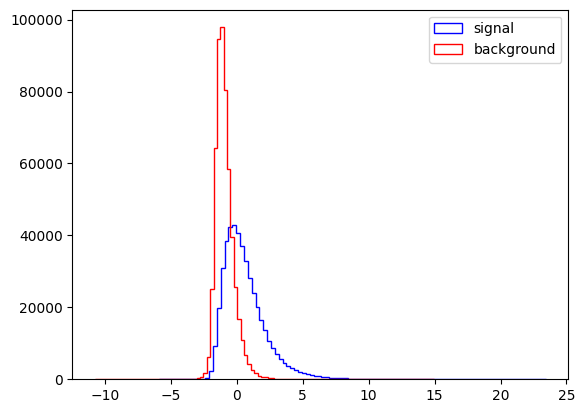

In [8]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True)
plt.legend(loc='upper right')
plt.show()

#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

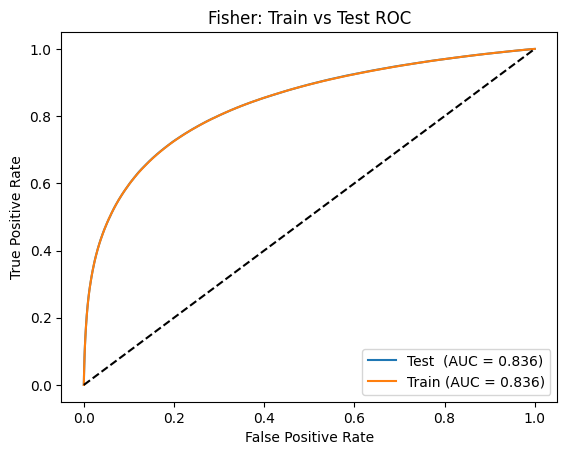

In [11]:
# Overfitting would show as a noticeably better AUC on the training sample
from sklearn.metrics import roc_curve, auc

fpr_test, tpr_test, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))
fpr_train, tpr_train, _ = roc_curve(y_Train, Fisher.decision_function(X_Train))

plt.plot(fpr_test,  tpr_test,  label='Test  (AUC = %0.3f)' % auc(fpr_test, tpr_test))
plt.plot(fpr_train, tpr_train, label='Train (AUC = %0.3f)' % auc(fpr_train, tpr_train))
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Fisher: Train vs Test ROC')
plt.legend(loc='lower right')
plt.show()

#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 

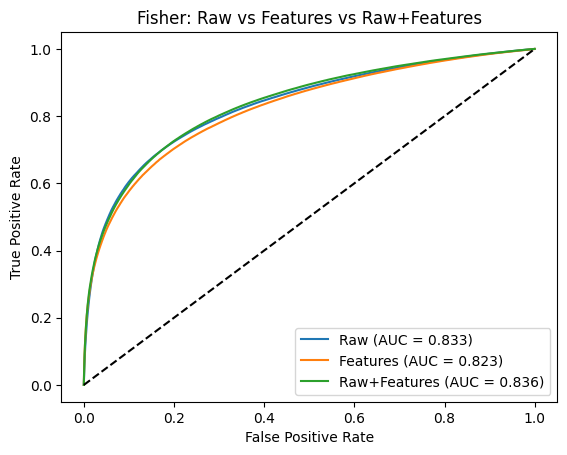

In [12]:
RawNames     = ["l_1_pT", "l_1_eta", "l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames = list(set(VarNames[1:]).difference(RawNames))

input_sets = {
    "Raw":          RawNames,
    "Features":     FeatureNames,
    "Raw+Features": VarNames[1:],
}

# Train a fresh Fisher classifier for each input set and overlay ROC curves
for name, cols in input_sets.items():
    clf = DA.LinearDiscriminantAnalysis()
    clf.fit(Train_Sample[cols], y_Train)
    fpr, tpr, _ = roc_curve(y_Test, clf.decision_function(Test_Sample[cols]))
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc(fpr, tpr):.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Fisher: Raw vs Features vs Raw+Features')
plt.legend(loc='lower right')
plt.show()

### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 5.

In [14]:
#Part A

# - Random Forest: ensemble of decision trees
# - Logistic Regression: simple linear classifier
# - Gradient Boosting: boosted decision trees (typically strongest performer)

Random Forest


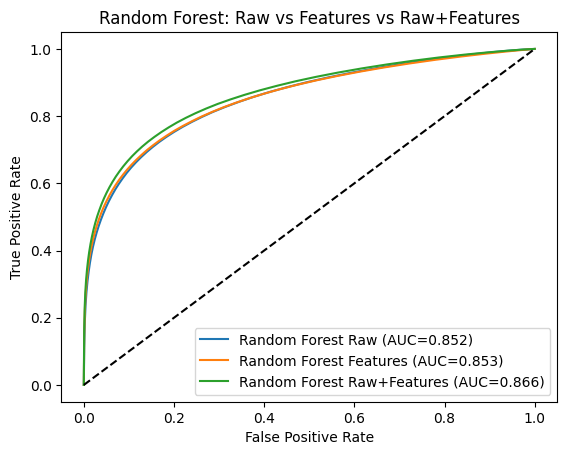

Logistic Regression


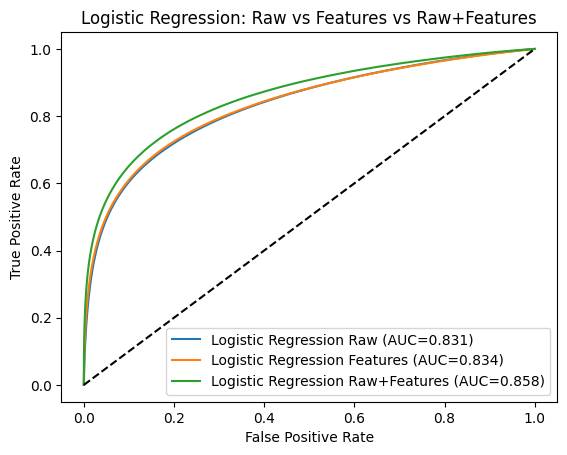

Gradient Boosting


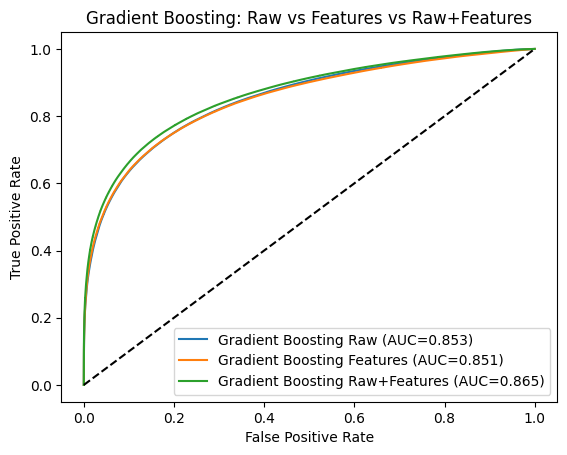

In [16]:
# compared across raw, features, and raw+features inputs
# Using 500k training events instead of 4M for speed

from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# Reduce training size for speed
N_Train = 500000
Train_Sample = df[:N_Train]
Test_Sample  = df[N_Train:]

X_Train = Train_Sample[VarNames[1:]]
y_Train = Train_Sample["signal"]
X_Test  = Test_Sample[VarNames[1:]]
y_Test  = Test_Sample["signal"]

Test_sig = Test_Sample[Test_Sample.signal==1]
Test_bkg = Test_Sample[Test_Sample.signal==0]

def compare_classifier(clf, clf_name, Train_Sample, Test_Sample, input_sets, y_Train, y_Test):
    for name, cols in input_sets.items():
        clf.fit(Train_Sample[cols], y_Train)
        # Use predict_proba if available, otherwise decision_function
        if hasattr(clf, "predict_proba"):
            scores = clf.predict_proba(Test_Sample[cols])[:, 1]
        else:
            scores = clf.decision_function(Test_Sample[cols])
        fpr, tpr, _ = roc_curve(y_Test, scores)
        plt.plot(fpr, tpr, label=f"{clf_name} {name} (AUC={auc(fpr,tpr):.3f})")

    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{clf_name}: Raw vs Features vs Raw+Features')
    plt.legend(loc='lower right')
    plt.show()

# Run for each classifier
classifiers = {
    "Random Forest":       RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=50, random_state=42),
}

for clf_name, clf in classifiers.items():
    print(clf_name)
    compare_classifier(clf, clf_name, Train_Sample, Test_Sample, input_sets, y_Train, y_Test)

In [17]:
# max significance across the 4 scenarios from Lab 7

best_clf = GradientBoostingClassifier(n_estimators=50, random_state=42)
best_clf.fit(Train_Sample[VarNames[1:]], y_Train)
scores = best_clf.predict_proba(Test_Sample[VarNames[1:]])[:, 1]

fpr, tpr, thresholds = roc_curve(y_Test, scores)

scenarios = {
    "1": (10,    100),
    "2": (100,   1000),
    "3": (1000,  10000),
    "4": (10000, 100000),
}

table = []
for name, (N_S, N_B) in scenarios.items():
    n_sig_prime = N_S * tpr
    n_bkg_prime = N_B * fpr
    sig = np.where((n_sig_prime + n_bkg_prime) > 0,
                   n_sig_prime / np.sqrt(n_sig_prime + n_bkg_prime), 0)
    max_i = np.argmax(sig)
    table.append((name, N_S, N_B, f"{tpr[max_i]:.4f}", f"{fpr[max_i]:.4f}",
                  f"{n_sig_prime[max_i]:.2f}", f"{n_bkg_prime[max_i]:.2f}", f"{sig[max_i]:.3f}"))

display(HTML(tabulate.tabulate(table, tablefmt='html',
                               headers=["Scenario", "N_S", "N_B", "TPR", "FPR", "N'_S", "N'_B", "Max Sig"])))

/var/folders/x9/93df7t7d28x1g7qqchyb99y40000gn/T/ipykernel_28210/544069661.py:21: RuntimeWarning: invalid value encountered in divide
  n_sig_prime / np.sqrt(n_sig_prime + n_bkg_prime), 0)


Scenario,N_S,N_B,TPR,FPR,N'_S,N'_B,Max Sig
1,10,100,0.467,0.0247,4.67,2.47,1.747
2,100,1000,0.467,0.0247,46.7,24.74,5.525
3,1000,10000,0.467,0.0247,467,247.36,17.473
4,10000,100000,0.467,0.0247,4670.04,2473.56,55.254


### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

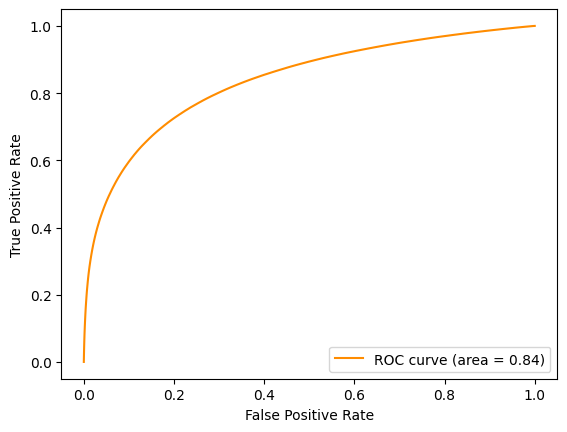

In [18]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()


#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 


In [19]:
# for the best classifier across all 4 scenarios, using sklearn metrics

from sklearn.metrics import (roc_curve, auc, precision_score, recall_score,
                             f1_score, accuracy_score)

# Get binary predictions and scores from best classifier
scores   = best_clf.predict_proba(Test_Sample[VarNames[1:]])[:, 1]
fpr, tpr, thresholds = roc_curve(y_Test, scores)
roc_auc  = auc(fpr, tpr)

table = []
for name, (N_S, N_B) in scenarios.items():
    # Compute max significance and optimal threshold
    n_sig_prime = N_S * tpr
    n_bkg_prime = N_B * fpr
    sig = np.where((n_sig_prime + n_bkg_prime) > 0,
                   n_sig_prime / np.sqrt(n_sig_prime + n_bkg_prime), 0)
    max_i     = np.argmax(sig)
    threshold = thresholds[max_i]

    # Apply optimal threshold to get binary predictions
    y_pred = (scores >= threshold).astype(int)

    # Compute all metrics at this threshold
    precision = precision_score(y_Test, y_pred, zero_division=0)
    recall    = recall_score(y_Test, y_pred)
    f1        = f1_score(y_Test, y_pred)
    accuracy  = accuracy_score(y_Test, y_pred)

    table.append((name, N_S, N_B,
                  f"{tpr[max_i]:.3f}", f"{fpr[max_i]:.3f}",
                  f"{roc_auc:.3f}",
                  f"{precision:.3f}", f"{recall:.3f}",
                  f"{f1:.3f}", f"{accuracy:.3f}",
                  f"{sig[max_i]:.3f}"))

display(HTML(tabulate.tabulate(table, tablefmt='html',
                               headers=["Scenario", "N_S", "N_B", "TPR", "FPR",
                                        "AUC", "Precision", "Recall", "F1",
                                        "Accuracy", "Max Sig"])))

/var/folders/x9/93df7t7d28x1g7qqchyb99y40000gn/T/ipykernel_28210/1596629610.py:17: RuntimeWarning: invalid value encountered in divide
  n_sig_prime / np.sqrt(n_sig_prime + n_bkg_prime), 0)
/var/folders/x9/93df7t7d28x1g7qqchyb99y40000gn/T/ipykernel_28210/1596629610.py:17: RuntimeWarning: invalid value encountered in divide
  n_sig_prime / np.sqrt(n_sig_prime + n_bkg_prime), 0)
/var/folders/x9/93df7t7d28x1g7qqchyb99y40000gn/T/ipykernel_28210/1596629610.py:17: RuntimeWarning: invalid value encountered in divide
  n_sig_prime / np.sqrt(n_sig_prime + n_bkg_prime), 0)
/var/folders/x9/93df7t7d28x1g7qqchyb99y40000gn/T/ipykernel_28210/1596629610.py:17: RuntimeWarning: invalid value encountered in divide
  n_sig_prime / np.sqrt(n_sig_prime + n_bkg_prime), 0)


Scenario,N_S,N_B,TPR,FPR,AUC,Precision,Recall,F1,Accuracy,Max Sig
1,10,100,0.467,0.025,0.865,0.941,0.467,0.624,0.743,1.747
2,100,1000,0.467,0.025,0.865,0.941,0.467,0.624,0.743,5.525
3,1000,10000,0.467,0.025,0.865,0.941,0.467,0.624,0.743,17.473
4,10000,100000,0.467,0.025,0.865,0.941,0.467,0.624,0.743,55.254
